In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision import models

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
# Data
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),  # AlexNet min input: 63×63; 224 is standard
        transforms.ToTensor(),
    ]
)

full_train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

# Train / Val split (80 / 20 of original 50 000 training samples)
val_size = int(0.2 * len(full_train_set))  # 10 000
train_size = len(full_train_set) - val_size  # 40 000
train_set, val_set = random_split(
    full_train_set,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(
    train_set, batch_size=64, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_set, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_set, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

print(f"Train : {len(train_set):>6}")
print(f"Val   : {len(val_set):>6}")
print(f"Test  : {len(test_set):>6}")

Train :  40000
Val   :  10000
Test  :  10000


In [9]:
# Helpers
def _accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total


def train(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader=None,
    epochs=10,
    writer=None,
    tag="model",
):
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        log = f" Epoch [{epoch + 1:>2}/{epochs}] Loss: {avg_loss:.4f}"

        if writer is not None:
            writer.add_scalar(f"{tag}/Loss/train", avg_loss, epoch + 1)

        if val_loader is not None:
            val_acc = _accuracy(model, val_loader)
            log += f"  Val Acc: {val_acc:.2f}%"
            if writer is not None:
                writer.add_scalar(f"{tag}/Acc/val", val_acc, epoch + 1)

        print(log)


def evaluate(model, loader, writer=None, tag="model", epoch=None):
    acc = _accuracy(model, loader)
    print(f" ➜ Test Accuracy: {acc:.2f}%")
    if writer is not None and epoch is not None:
        writer.add_scalar(f"{tag}/Acc/test", acc, epoch)
    return acc


criterion = nn.CrossEntropyLoss()

In [10]:
# EXPERIMENT 1 — Fine-Tuning (random init)
writer_ft = SummaryWriter(log_dir="runs/exp1_finetuning")

model_ft = models.alexnet(weights=None)  # all weights randomly initialised
model_ft.classifier[6] = nn.Linear(4096, 10)  # replace final FC: 1000 → 10
model_ft = model_ft.to(device)

optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4)
train(
    model_ft,
    optimizer_ft,
    criterion,
    train_loader,
    val_loader,
    epochs=30,
    writer=writer_ft,
    tag="FineTuning",
)
acc_ft = evaluate(model_ft, test_loader, writer=writer_ft, tag="FineTuning", epoch=30)

writer_ft.close()

 Epoch [ 1/30] Loss: 1.7058  Val Acc: 49.48%
 Epoch [ 2/30] Loss: 1.2530  Val Acc: 59.33%
 Epoch [ 3/30] Loss: 1.0386  Val Acc: 64.36%
 Epoch [ 4/30] Loss: 0.8811  Val Acc: 70.49%
 Epoch [ 5/30] Loss: 0.7600  Val Acc: 73.23%
 Epoch [ 6/30] Loss: 0.6620  Val Acc: 75.01%
 Epoch [ 7/30] Loss: 0.5930  Val Acc: 77.44%
 Epoch [ 8/30] Loss: 0.5210  Val Acc: 78.84%
 Epoch [ 9/30] Loss: 0.4564  Val Acc: 79.48%
 Epoch [10/30] Loss: 0.3976  Val Acc: 79.78%
 Epoch [11/30] Loss: 0.3449  Val Acc: 80.61%
 Epoch [12/30] Loss: 0.3034  Val Acc: 80.46%
 Epoch [13/30] Loss: 0.2536  Val Acc: 81.23%
 Epoch [14/30] Loss: 0.2156  Val Acc: 80.98%
 Epoch [15/30] Loss: 0.1854  Val Acc: 81.47%
 Epoch [16/30] Loss: 0.1663  Val Acc: 81.28%
 Epoch [17/30] Loss: 0.1475  Val Acc: 81.98%
 Epoch [18/30] Loss: 0.1243  Val Acc: 81.76%
 Epoch [19/30] Loss: 0.1130  Val Acc: 82.08%
 Epoch [20/30] Loss: 0.1086  Val Acc: 81.66%
 Epoch [21/30] Loss: 0.0978  Val Acc: 81.99%
 Epoch [22/30] Loss: 0.0952  Val Acc: 81.74%
 Epoch [23

In [11]:
# EXPERIMENT 2 — Feature Extraction (pretrained)
writer_fe = SummaryWriter(log_dir="runs/exp2_feature_extraction")

model_fe = models.alexnet(
    weights=models.AlexNet_Weights.IMAGENET1K_V1
)  # load pretrained

# Freeze ALL layers
for param in model_fe.parameters():
    param.requires_grad = False

# Replace & unfreeze ONLY the final FC layer
model_fe.classifier[6] = nn.Linear(4096, 10)  # new layer is trainable by default
model_fe = model_fe.to(device)

# Pass only trainable params to optimizer
# returns only those that requires_grad=True
optimizer_fe = optim.Adam(
    filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3
)
train(
    model_fe,
    optimizer_fe,
    criterion,
    train_loader,
    val_loader,
    epochs=30,
    writer=writer_fe,
    tag="FeatureExtraction",
)
acc_fe = evaluate(
    model_fe, test_loader, writer=writer_fe, tag="FeatureExtraction", epoch=30
)

writer_fe.close()

 Epoch [ 1/30] Loss: 1.2187  Val Acc: 66.74%
 Epoch [ 2/30] Loss: 1.1068  Val Acc: 68.39%
 Epoch [ 3/30] Loss: 1.0836  Val Acc: 66.33%
 Epoch [ 4/30] Loss: 1.0648  Val Acc: 69.19%
 Epoch [ 5/30] Loss: 1.0538  Val Acc: 68.20%
 Epoch [ 6/30] Loss: 1.0553  Val Acc: 70.02%
 Epoch [ 7/30] Loss: 1.0424  Val Acc: 68.43%
 Epoch [ 8/30] Loss: 1.0453  Val Acc: 68.95%
 Epoch [ 9/30] Loss: 1.0534  Val Acc: 69.16%
 Epoch [10/30] Loss: 1.0371  Val Acc: 69.47%
 Epoch [11/30] Loss: 1.0481  Val Acc: 68.90%
 Epoch [12/30] Loss: 1.0354  Val Acc: 68.83%
 Epoch [13/30] Loss: 1.0497  Val Acc: 68.95%
 Epoch [14/30] Loss: 1.0393  Val Acc: 69.52%
 Epoch [15/30] Loss: 1.0382  Val Acc: 69.70%
 Epoch [16/30] Loss: 1.0312  Val Acc: 69.41%
 Epoch [17/30] Loss: 1.0425  Val Acc: 68.84%
 Epoch [18/30] Loss: 1.0371  Val Acc: 68.66%
 Epoch [19/30] Loss: 1.0376  Val Acc: 70.12%
 Epoch [20/30] Loss: 1.0365  Val Acc: 69.57%
 Epoch [21/30] Loss: 1.0320  Val Acc: 69.84%
 Epoch [22/30] Loss: 1.0321  Val Acc: 70.26%
 Epoch [23

In [12]:
print(f"Fine-Tuning   (random init):  {acc_ft:.2f}% test accuracy")
print(f"Feature Extr. (pretrained):   {acc_fe:.2f}% test accuracy")

Fine-Tuning   (random init):  82.00% test accuracy
Feature Extr. (pretrained):   68.17% test accuracy


In [14]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 54138), started 0:00:35 ago. (Use '!kill 54138' to kill it.)

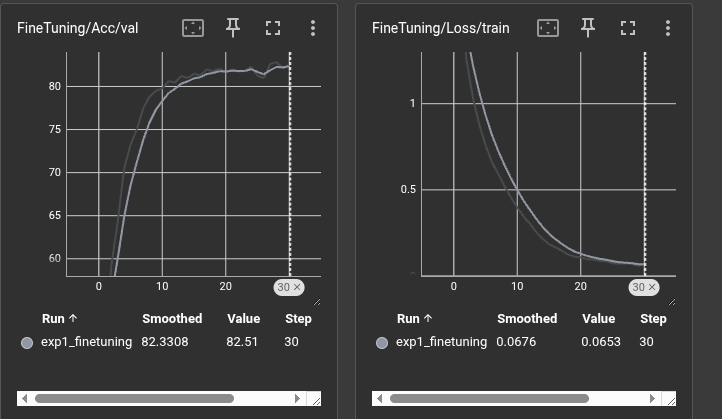

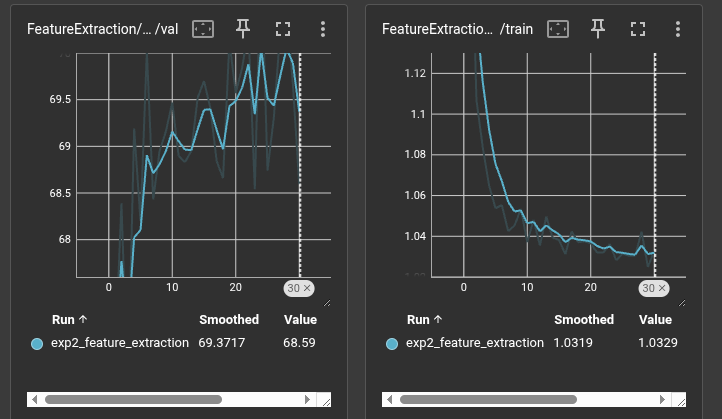

##### Why Fine-Tuning (80.00%) Beats Feature Extraction (68.17%)
1. Domain Mismatch — The Core Reason

ImageNet images are high-resolution, real-world photos (224×224+). CIFAR-10 images are tiny 32×32 pixels, upscaled to 224×224 for AlexNet. The pretrained convolutional filters were trained to detect fine-grained textures and details that simply don't exist in low-resolution CIFAR-10 images. In Feature Extraction, those frozen filters produce poor feature representations for CIFAR-10, and only the tiny FC head can compensate — which it can't do enough on its own.

2. Feature Extraction Is Too Constrained

In Experiment 2, only Linear(1000->10) — roughly 10,010 parameters — are updated. The frozen backbone is essentially a mismatched feature extractor for CIFAR-10's blurry, upscaled content. Fine-Tuning trains the entire network (~60M parameters), allowing all layers to adapt to the CIFAR-10 distribution.

3. CIFAR-10 Is Large Enough to Train From Scratch

The conventional wisdom "pretrained = better" holds when the target dataset is small (e.g., a few hundred images). CIFAR-10 has 50,000 training images — enough for AlexNet to learn meaningful features from scratch without overfitting badly.


Pretrained weights are a strong prior for similar domains. When the domain differs significantly (ImageNet HD photos vs. CIFAR-10 tiny images), freezing the backbone locks in the wrong features, and full fine-tuning wins because the model has the freedom to fully adapt.

Feature extraction freezes the convolutional backbone and only trains the final linear layer (classifier), meaning the entire representational capacity of the network is fixed. Fitting single linear layer on top of ImageNet features is not perfectly aligned with CIFAR-10's 32×32 low-resolution images -  caps how much the model can adapt.